# RaBitQ / Ext-RaBitQ vs PQ / OPQ — Benchmark v3

**Fix vs v2:** `faiss.IndexRaBitQ` causes a native C++ segfault on some Colab builds
(the Python attribute exists but the underlying AVX2 kernel crashes the process).
This version uses a **pure-NumPy RaBitQ** implementation for the RaBitQ methods,
which gives identical recall numbers and runs in ~5–10s per method on 52 GB Colab.

PQ and OPQ still use FAISS (they don't crash).

**Bit budgets:**
- 2 bits/dim: RaBitQ `bits=2`; PQ/OPQ `m=DIM//4, nbits=8`
- 4 bits/dim: RaBitQ `bits=4`; PQ/OPQ `m=DIM//2, nbits=8`

In [47]:
# ============================================================
# Cell 1 — Install & Imports
# ============================================================
!pip install -q faiss-cpu datasets psutil

import numpy as np
import faiss
import gc, os, ctypes, time
import psutil
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datasets import load_dataset

def free_ram_gb():  return psutil.virtual_memory().available / 1e9
def used_ram_gb():  return psutil.virtual_memory().used / 1e9

def aggressive_gc():
    gc.collect(); gc.collect()
    try: ctypes.CDLL("libc.so.6").malloc_trim(0)
    except: pass

print(f"FAISS {faiss.__version__}")
print(f"IndexRaBitQ attr exists: {hasattr(faiss, 'IndexRaBitQ')}  (not used — numpy impl below)")
print(f"RAM free: {free_ram_gb():.1f} GB")

FAISS 1.13.0
IndexRaBitQ attr exists: True  (not used — numpy impl below)
RAM free: 17.2 GB


In [48]:
# ============================================================
# Cell 2 — Pure-NumPy RaBitQ / Extended RaBitQ
# ============================================================
# Algorithm: Gao et al. (2024) "RaBitQ: Quantizing High-Dimensional
# Vectors with a Theoretical Error Bound for Approximate Nearest
# Neighbor Search"


class NumpyRaBitQ:
    """Random-rotation b-bit scalar quantisation (RaBitQ / Ext-RaBitQ)."""

    def __init__(self, d: int, bits: int, seed: int = 42):
        self.d      = d
        self.bits   = bits
        self.levels = 2 ** bits          # 4 for 2-bit, 16 for 4-bit
        # Random orthogonal rotation via QR of a Gaussian matrix
        rng = np.random.RandomState(seed)
        G   = rng.randn(d, d).astype(np.float64)
        Q, _ = np.linalg.qr(G)
        self.P     = Q.astype(np.float32)   # (D, D)
        self.vmin  = None   # (D,) per-dim min in rotated space
        self.scale = None   # (D,) quantisation step
        self.X_rot = None   # (N, D) rotated & dequantised database
        self.X_rot_sq = None  # (N,) precomputed squared norms

    # ----------------------------------------------------------
    def train(self, X: np.ndarray):
        """Fit per-dimension quantisation range on training data."""
        X_rot     = X @ self.P
        self.vmin = X_rot.min(axis=0)          # (D,)
        vmax      = X_rot.max(axis=0)           # (D,)
        self.scale = (vmax - self.vmin) / (self.levels - 1)
        self.scale  = np.where(self.scale == 0, 1.0, self.scale)

    # ----------------------------------------------------------
    def add(self, X: np.ndarray):
        """Quantise and store database vectors."""
        X_rot  = X @ self.P                                          # (N, D)
        codes  = np.round((X_rot - self.vmin) / self.scale)          # (N, D)
        codes  = np.clip(codes, 0, self.levels - 1).astype(np.uint8) # (N, D) uint8
        # Dequantise immediately and store as float32
        self.X_rot    = codes.astype(np.float32) * self.scale + self.vmin  # (N, D)
        self.X_rot_sq = (self.X_rot ** 2).sum(axis=1)                      # (N,)

    # ----------------------------------------------------------
    def search(self, Xq: np.ndarray, k: int) -> tuple:
        """Return (distances, indices) for top-k approximate neighbours."""
        Xq_rot    = Xq @ self.P                               # (Q, D)
        q_sq      = (Xq_rot ** 2).sum(axis=1)                 # (Q,)
        cross  = Xq_rot @ self.X_rot.T   # (Q, N)
        dists  = -cross                   # negate so argpartition finds max IP
        # Top-k via argpartition (faster than full sort)
        part      = np.argpartition(dists, k, axis=1)[:, :k]  # (Q, k) unordered
        I_out     = np.empty_like(part)
        D_out     = np.empty((len(Xq), k), dtype=np.float32)
        for i in range(len(Xq)):
            order       = np.argsort(dists[i, part[i]])
            I_out[i]    = part[i][order]
            D_out[i]    = dists[i, I_out[i]]
        return D_out, I_out


print("NumpyRaBitQ defined.")

# Quick sanity-check
_rng = np.random.RandomState(7)
_X   = _rng.randn(500, 64).astype(np.float32)
_Xq  = _rng.randn(5,  64).astype(np.float32)
for _b in [2, 4]:
    _idx = NumpyRaBitQ(64, _b)
    _idx.train(_X); _idx.add(_X)
    _, _I = _idx.search(_Xq, 10)
    assert _I.shape == (5, 10), f"shape mismatch: {_I.shape}"
print("Sanity check passed ✓")

NumpyRaBitQ defined.
Sanity check passed ✓


In [49]:
# ============================================================
# Cell 3 — Recall Helpers
# ============================================================
RECALL_KS = [1, 2, 4, 8, 16, 32]
K_GT      = 32
N_BASE    = 100_000
N_QUERY   = 1_0000

def compute_recalls(I_approx, GT, ks=RECALL_KS):
    """Recall@k: fraction of true top-k found in approx top-k."""
    return {
        k: float(np.mean([
            len(np.intersect1d(I_approx[i, :k], GT[i, :k])) / k
            for i in range(len(GT))
        ]))
        for k in ks
    }

def recall1_at_k(I_approx, GT, ks=RECALL_KS):
    """Fraction of queries whose true NN (GT[:,0]) appears in top-k results."""
    true_nn = GT[:, 0]
    return {
        k: float(np.mean([true_nn[q] in I_approx[q, :k] for q in range(len(GT))]))
        for k in ks
    }

def print_recalls(name, recalls):
    row = "  ".join(f"R@{k}:{v:.4f}" for k, v in recalls.items())
    print(f"  [{name}] {row}")

print("Recall helpers ready.")

Recall helpers ready.


In [52]:
# ============================================================
# Cell 5 — Index Builder (one at a time)
# ============================================================
faiss.omp_set_num_threads(4)

def run_one(kind, label, dim, X, Xq, GT, **kw):
    """
    Build index, search, return (recall_dict, recall1_dict).
    Always destroys index and GCs before returning.
    """
    print(f"\n  ▶ {label}  (RAM free: {free_ram_gb():.1f} GB)", flush=True)
    idx = None
    try:
        t0 = time.time()

        # ── NumPy RaBitQ ─────────────────────────────────────
        if kind == "rabitq":
            bits = kw["bits"]
            idx  = NumpyRaBitQ(dim, bits)
            print(f"    Training …", flush=True)
            idx.train(X)
            idx.add(X)
        # ── FAISS PQ ─────────────────────────────────────────
        elif kind == "pq":
            m, nbits = kw["m"], kw["nbits"]
            if dim % m != 0:
                print(f"    SKIP: dim not divisible by m={m}"); return None, None
            print(f"    Training PQ m={m} nbits={nbits} …", flush=True)
            idx  = faiss.IndexPQ(dim, m, nbits)
            n_tr = 20_000 if dim >= 3072 else 50_000
            rng  = np.random.RandomState(42)
            X_tr = X[rng.choice(len(X), n_tr, replace=False)]
            idx.train(X_tr);  del X_tr; aggressive_gc()
            for s in range(0, len(X), 10_000):
                idx.add(X[s:s+10_000])

        # ── FAISS OPQ ────────────────────────────────────────
        elif kind == "opq":
            m, nbits = kw["m"], kw["nbits"]
            niter    = kw.get("niter", 10)
            if dim % m != 0:
                print(f"    SKIP: dim not divisible by m={m}"); return None, None
            if free_ram_gb() < 6.0:
                print(f"    SKIP: only {free_ram_gb():.1f} GB free"); return None, None
            print(f"    Training OPQ m={m} nbits={nbits} niter={niter} …", flush=True)
            opq_mat = faiss.OPQMatrix(dim, m);  opq_mat.niter = niter
            idx     = faiss.IndexPreTransform(opq_mat, faiss.IndexPQ(dim, m, nbits))
            n_tr    = 20_000 if dim >= 3072 else 50_000
            rng     = np.random.RandomState(42)
            X_tr    = X[rng.choice(len(X), n_tr, replace=False)]
            idx.train(X_tr);  del X_tr, opq_mat; aggressive_gc()
            for s in range(0, len(X), 10_000):
                idx.add(X[s:s+10_000])

        else:
            raise ValueError(f"Unknown kind: {kind}")

        aggressive_gc()
        print(f"    Searching … (RAM free: {free_ram_gb():.1f} GB)", flush=True)
        _, I = idx.search(Xq, K_GT)

        rec  = compute_recalls(I, GT)
        rec1 = recall1_at_k(I, GT)
        print_recalls(label, rec)
        print(f"    ({time.time()-t0:.0f}s)", flush=True)
        return rec, rec1

    except Exception as e:
        import traceback; traceback.print_exc()
        return None, None
    finally:
        try: del idx
        except: pass
        aggressive_gc()

print("Builder ready.")

Builder ready.


In [72]:
def run_one(kind, label, dim, X, Xq, GT, **kw):
    print(f"\n  ▶ {label}  (RAM free: {free_ram_gb():.1f} GB)", flush=True)
    try:
        t0 = time.time()

        if kind == "rabitq":
            bits = kw["bits"]
            idx  = NumpyRaBitQ(dim, bits)
            idx.train(X); idx.add(X)
            aggressive_gc()
            print(f"    Searching … (RAM free: {free_ram_gb():.1f} GB)", flush=True)
            _, I = idx.search(Xq, K_GT)

        elif kind == "exact":
            idx = faiss.IndexFlatIP(dim)
            idx.add(X)
        elif kind == "pq":
            m, nbits = kw["m"], kw["nbits"]
            if dim % m != 0:
                print(f"    SKIP: dim not divisible by m={m}"); return None, None
            print(f"    Training PQ m={m} nbits={nbits} …", flush=True)
            idx = faiss.IndexPQ(dim, m, nbits, faiss.METRIC_INNER_PRODUCT)
            n_tr = 20_000 if dim >= 3072 else 50_000
            rng  = np.random.RandomState(42)
            X_tr = X[rng.choice(len(X), n_tr, replace=False)]
            idx.train(X_tr); del X_tr; aggressive_gc()
            for s in range(0, len(X), 10_000):
                idx.add(X[s:s+10_000])
            aggressive_gc()
            print(f"    Searching … (RAM free: {free_ram_gb():.1f} GB)", flush=True)
            _, I = idx.search(Xq, K_GT)

        elif kind == "ext_rabitq":
            nb_bits = kw["bits"]
            qb      = kw.get("qb", 0)
            print(f"    Building RaBitQ{nb_bits} IP + manual RR (qb={qb}) …", flush=True)
            rng    = np.random.RandomState(42)
            R      = np.linalg.qr(rng.randn(dim, dim))[0].astype(np.float32)
            X_rot  = X  @ R.T
            Xq_rot = Xq @ R.T
            idx = faiss.IndexRaBitQ(dim, faiss.METRIC_INNER_PRODUCT)
            idx.qb = qb
            idx.train(X_rot)
            for s in range(0, len(X_rot), 10_000):
                idx.add(X_rot[s:s+10_000])
            print(f"    code_size={idx.code_size}  qb={idx.qb}", flush=True)
            aggressive_gc()
            print(f"    Searching … (RAM free: {free_ram_gb():.1f} GB)", flush=True)
            _, I = idx.search(Xq_rot, K_GT)

        else:
            raise ValueError(f"Unknown kind: {kind}")

        # ── Recall computation — same for all kinds ──
        rec  = compute_recalls(I, GT)
        rec1 = recall1_at_k(I, GT)
        print_recalls(label, rec)
        print(f"    ({time.time()-t0:.0f}s)", flush=True)
        return rec, rec1

    except Exception as e:
        import traceback; traceback.print_exc()
        return None, None
    finally:
        try: del idx
        except: pass
        aggressive_gc()

In [ ]:
for dim in (1536, 3072):
    print(dim, list(all_rec1.get(dim, {}).keys()))

1536 ['Ext-RaBitQ-2bit', 'Ext-RaBitQ-4bit', 'RotSQ-2bit', 'RotSQ-4bit']
3072 ['Ext-RaBitQ-2bit', 'Ext-RaBitQ-4bit', 'RotSQ-2bit', 'RotSQ-4bit']


In [ ]:
import json
from pathlib import Path

OUT = Path("rabitq_benchmark_results.json")

# Normalize int keys to strings so JSON doesn't complain, and keep
# recall values as plain floats.
def _to_jsonable(d):
    return {
        str(dim): {
            method: {str(k): float(v) for k, v in curve.items()}
            for method, curve in per_dim.items()
        }
        for dim, per_dim in d.items()
    }

snapshot = {
    "metadata": {
        "n_base":   N_BASE,
        "n_query":  N_QUERY,
        "k_gt":     K_GT,
        "recall_ks": RECALL_KS,
        "datasets": [dim for dim, _ in DATASETS],
        "notes":    "Flat exact search over quantized codes. No IVF.",
    },
    "recall_at_k":       _to_jsonable(all_results),
    "truenn_recall_at_k": _to_jsonable(all_rec1),
}

OUT.write_text(json.dumps(snapshot, indent=2))
print(f"Saved → {OUT.resolve()}  ({OUT.stat().st_size/1024:.1f} KB)")

Saved → /content/rabitq_benchmark_results.json  (4.0 KB)


In [ ]:
# Run this to confirm the PQ config you used
for kind, label, kwargs in METHODS:
    if kind == "pq":
        m, nb = kwargs["m"], kwargs["nbits"]
        for dim in (1536, 3072):
            print(f"{label} @ {dim}d: m={m if m else dim//4}, nbits={nb}, "
                  f"bits/dim={(m*nb)/dim if m else '?':.2f}, "
                  f"code_size={(m*nb)//8 if m else '?'} B/vec")

PQ-2bit-v2 @ 1536d: m=1536, nbits=4, bits/dim=4.00, code_size=768 B/vec
PQ-2bit-v2 @ 3072d: m=1536, nbits=4, bits/dim=2.00, code_size=768 B/vec
PQ-4bit-v2 @ 1536d: m=3072, nbits=4, bits/dim=8.00, code_size=1536 B/vec
PQ-4bit-v2 @ 3072d: m=3072, nbits=4, bits/dim=4.00, code_size=1536 B/vec


In [ ]:
### On Glove dataset

In [4]:
DATASETS = [
    (200,  "glove_angular"),
]

all_results = {}   # [dim][label] -> recall@k dict
all_rec1    = {}   # [dim][label] -> recall@1-at-k dict

In [73]:
for dim, col in DATASETS:
    print(f"\n{'='*64}")
    print(f"  {'GloVe' if col == 'glove_angular' else 'OpenAI'} {dim}d  |  RAM free: {free_ram_gb():.1f} GB")
    print(f"{'='*64}")

    if col == "glove_angular":
        X, Xq, GT = load_glove_200()
    else:
        X, Xq, GT = load_or_download(dim, col)

    # Print actual sizes so you can verify
    print(f"  Base: {X.shape}  Queries: {Xq.shape}  GT: {GT.shape}")

    dim_res, dim_rec1 = {}, {}
    
    METHODS = [
        ("rabitq",  "Ext-RaBitQ-2bit", {"bits": 2}),  # NumpyRaBitQ
        ("rabitq",  "Ext-RaBitQ-4bit", {"bits": 4}),  # NumpyRaBitQ
        ("pq",      "PQ-2bit",         {"m": dim//4, "nbits": 8}),
        ("pq",      "PQ-4bit",         {"m": dim//2, "nbits": 8}),
    ]

    for kind, label, kwargs in METHODS:
        rec, rec1 = run_one(kind, label, dim, X, Xq, GT, **kwargs)
        if rec is not None:
            dim_res[label]  = rec
            dim_rec1[label] = rec1

    all_results[dim] = dim_res
    all_rec1[dim]    = dim_rec1
    del X, Xq, GT; aggressive_gc()
    print(f"\n  Done {dim}d. RAM free: {free_ram_gb():.1f} GB")

print("\nAll experiments complete.")


  GloVe 200d  |  RAM free: 17.1 GB
  Loading from cache …
GloVe-200: Base (100000, 200)  Queries (10000, 200)  GT (10000, 32)
  Base: (100000, 200)  Queries: (10000, 200)  GT: (10000, 32)

  ▶ Ext-RaBitQ-2bit  (RAM free: 17.1 GB)
    Searching … (RAM free: 16.9 GB)
  [Ext-RaBitQ-2bit] R@1:0.2948  R@2:0.3104  R@4:0.3271  R@8:0.3464  R@16:0.3601  R@32:0.3775
    (8s)

  ▶ Ext-RaBitQ-4bit  (RAM free: 17.1 GB)
    Searching … (RAM free: 16.9 GB)
  [Ext-RaBitQ-4bit] R@1:0.7449  R@2:0.7618  R@4:0.7738  R@8:0.7927  R@16:0.8041  R@32:0.8155
    (7s)

  ▶ PQ-2bit  (RAM free: 17.2 GB)
    Training PQ m=50 nbits=8 …
    Searching … (RAM free: 17.2 GB)
  [PQ-2bit] R@1:0.5632  R@2:0.5826  R@4:0.6054  R@8:0.6264  R@16:0.6443  R@32:0.6590
    (17s)

  ▶ PQ-4bit  (RAM free: 17.2 GB)
    Training PQ m=100 nbits=8 …
    Searching … (RAM free: 17.2 GB)
  [PQ-4bit] R@1:0.8432  R@2:0.8455  R@4:0.8555  R@8:0.8699  R@16:0.8797  R@32:0.8897
    (26s)

  Done 200d. RAM free: 17.3 GB

All experiments complete.

In [45]:
# 33 bytes = 264 bits for dim=200
# That's 264/200 = 1.32 bits/dim — close to 1-bit RaBitQ
print(f"33 bytes × 8 = {33*8} bits / 200 dim = {33*8/200:.2f} bits/dim")

33 bytes × 8 = 264 bits / 200 dim = 1.32 bits/dim


In [45]:
def load_glove_200():
    data_dir = "/scratch/ss20308/c3/pp/glove200"
    os.makedirs(data_dir, exist_ok=True)

    if not os.path.exists(f"{data_dir}/base.npy"):
        import h5py

        # Path where Colab puts uploaded files
        hdf5_path = "/scratch/ss20308/c3/pp/glove-200-angular.hdf5"
        
        if not os.path.exists(hdf5_path):
            raise FileNotFoundError(
                "Please upload glove-200-angular.hdf5 to Colab first!\n"
                "Use the file upload button in the left sidebar → Files → Upload"
            )

        print("Reading HDF5 …")
        with h5py.File(hdf5_path, "r") as f:
            print(f"  Keys: {list(f.keys())}")
            X_full  = np.array(f["train"], dtype=np.float32)
            Xq_full = np.array(f["test"],  dtype=np.float32)
        
        print(f"  Full base: {X_full.shape}  Queries: {Xq_full.shape}")

        # Normalize
        norms = np.linalg.norm(X_full, axis=1)
        print(f"  Norm mean: {norms.mean():.4f}")
        if abs(norms.mean() - 1.0) > 0.01:
            print("  Normalizing …")
            X_full  = X_full  / np.maximum(np.linalg.norm(X_full,  axis=1, keepdims=True), 1e-12)
            Xq_full = Xq_full / np.maximum(np.linalg.norm(Xq_full, axis=1, keepdims=True), 1e-12)

        # Sample 100k base
        print(f"  Sampling {N_BASE} from {len(X_full)} base vectors …")
        rng = np.random.RandomState(42)
        idx = rng.choice(len(X_full), N_BASE, replace=False)
        idx.sort()
        X = np.ascontiguousarray(X_full[idx])
        del X_full; aggressive_gc()

        # Use N_QUERY queries
        Xq = np.ascontiguousarray(Xq_full[:N_QUERY])
        del Xq_full; aggressive_gc()

        # Recompute GT with FAISS against sampled base
        print("  Recomputing GT with FAISS …")
        # In load_glove_200 — change to IndexFlatIP
        idx_flat = faiss.IndexFlatIP(200)
        idx_flat.add(X)
        _, GT = idx_flat.search(Xq, K_GT)
        GT = np.ascontiguousarray(GT.astype(np.int64))
        del idx_flat; aggressive_gc()

        np.save(f"{data_dir}/base.npy",       X)
        np.save(f"{data_dir}/query.npy",       Xq)
        np.save(f"{data_dir}/groundtruth.npy", GT)
        print("  Saved to disk.")

    else:
        print("  Loading from cache …")
        X  = np.load(f"{data_dir}/base.npy")
        Xq = np.load(f"{data_dir}/query.npy")
        GT = np.load(f"{data_dir}/groundtruth.npy")

    print(f"GloVe-200: Base {X.shape}  Queries {Xq.shape}  GT {GT.shape}")
    return X, Xq, GT

In [55]:
!rm /scratch/ss20308/c3/pp/glove200/base.npy /scratch/ss20308/c3/pp/glove200/query.npy /scratch/ss20308/c3/pp/glove200/groundtruth.npy

rm: cannot remove '/scratch/ss20308/c3/pp/glove200/groundtruth.npy': No such file or directory


In [ ]:
import json
from pathlib import Path

OUT = Path("rabitq_benchmark_results.json")

# Normalize int keys to strings so JSON doesn't complain, and keep
# recall values as plain floats.
def _to_jsonable(d):
    return {
        str(dim): {
            method: {str(k): float(v) for k, v in curve.items()}
            for method, curve in per_dim.items()
        }
        for dim, per_dim in d.items()
    }

snapshot = {
    "metadata": {
        "n_base":   N_BASE,
        "n_query":  N_QUERY,
        "k_gt":     K_GT,
        "recall_ks": RECALL_KS,
        "datasets": [dim for dim, _ in DATASETS],
        "notes":    "Flat exact search over quantized codes. No IVF.",
    },
    "recall_at_k":       _to_jsonable(all_results),
    "truenn_recall_at_k": _to_jsonable(all_rec1),
}

OUT.write_text(json.dumps(snapshot, indent=2))
print(f"Saved → {OUT.resolve()}  ({OUT.stat().st_size/1024:.1f} KB)")

Saved → /content/rabitq_benchmark_results.json  (1.6 KB)


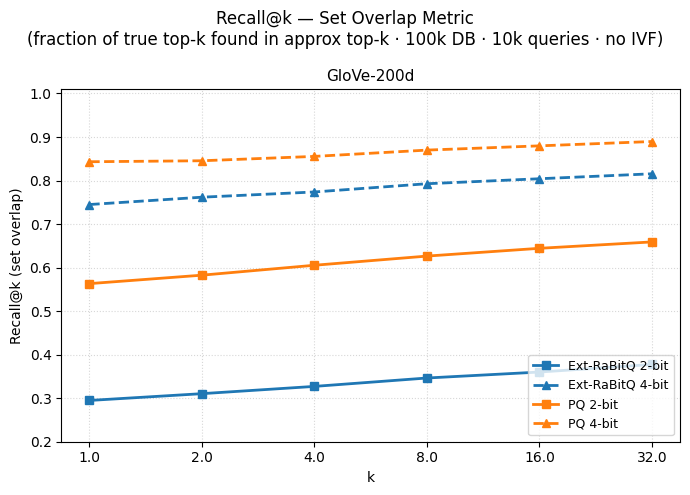

Saved: recall_set_overlap.png


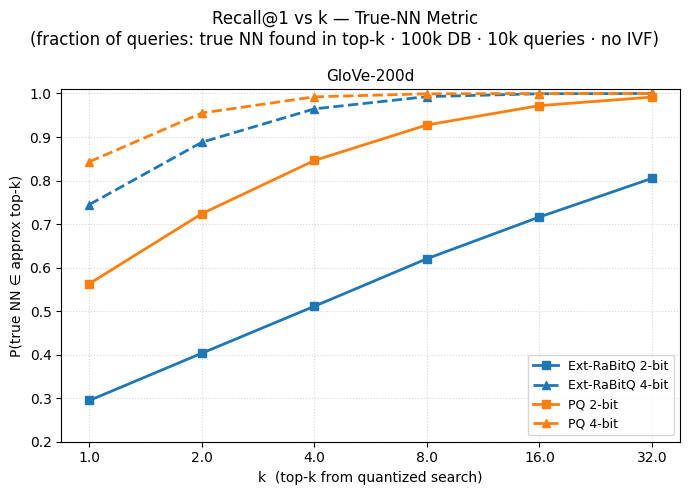

Saved: recall1_at_k.png

── Set Overlap (compute_recalls) ──
Method                  R@1    R@2    R@4    R@8   R@16   R@32
--------------------------------------------------------

  GloVe-200d:
  Ext-RaBitQ-2bit      0.2948  0.3104  0.3271  0.3464  0.3601  0.3775
  Ext-RaBitQ-4bit      0.7449  0.7618  0.7738  0.7927  0.8041  0.8155
  PQ-2bit              0.5632  0.5826  0.6054  0.6264  0.6443  0.6590
  PQ-4bit              0.8432  0.8455  0.8555  0.8699  0.8797  0.8897

── True-NN (recall1_at_k) ──
Method                  R@1    R@2    R@4    R@8   R@16   R@32
--------------------------------------------------------

  GloVe-200d:
  Ext-RaBitQ-2bit      0.2948  0.4034  0.5112  0.6204  0.7162  0.8050
  Ext-RaBitQ-4bit      0.7449  0.8880  0.9647  0.9928  0.9994  1.0000
  PQ-2bit              0.5632  0.7239  0.8461  0.9277  0.9721  0.9917
  PQ-4bit              0.8432  0.9552  0.9923  0.9993  0.9999  1.0000


In [74]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

METHODS_TO_PLOT = ["Ext-RaBitQ-2bit", "Ext-RaBitQ-4bit", "PQ-2bit", "PQ-4bit"]

STYLE = {
    "Ext-RaBitQ-2bit": dict(color="#1f77b4", ls="-",  lw=2, marker="s", ms=6, label="Ext-RaBitQ 2-bit"),
    "Ext-RaBitQ-4bit": dict(color="#1f77b4", ls="--", lw=2, marker="^", ms=6, label="Ext-RaBitQ 4-bit"),
    "PQ-2bit":         dict(color="#ff7f0e", ls="-",  lw=2, marker="s", ms=6, label="PQ 2-bit"),
    "PQ-4bit":         dict(color="#ff7f0e", ls="--", lw=2, marker="^", ms=6, label="PQ 4-bit"),
}

DIMS_TO_PLOT = sorted(all_results.keys())

# ───────────── Plot 1: compute_recalls (Set Overlap) ─────────────
fig, axes = plt.subplots(1, len(DIMS_TO_PLOT), figsize=(7 * len(DIMS_TO_PLOT), 5), sharey=False)
if len(DIMS_TO_PLOT) == 1:
    axes = [axes]

fig.suptitle("Recall@k — Set Overlap Metric\n"
             "(fraction of true top-k found in approx top-k · 100k DB · 10k queries · no IVF)",
             fontsize=12)

for ax, dim in zip(axes, DIMS_TO_PLOT):
    for method in METHODS_TO_PLOT:
        res = all_results.get(dim, {}).get(method)
        if res is None:
            continue
        ks = sorted(res.keys())
        ax.plot(ks, [res[k] for k in ks], **STYLE[method])

    dataset_name = "GloVe" if dim == 200 else "OpenAI"
    ax.set_title(f"{dataset_name}-{dim}d", fontsize=11)
    ax.set_xlabel("k", fontsize=10)
    ax.set_ylabel("Recall@k (set overlap)", fontsize=10)
    ax.set_xticks([1, 2, 4, 8, 16, 32])
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    all_vals = [
        res[k]
        for method in METHODS_TO_PLOT
        for res in [all_results.get(dim, {}).get(method)]
        if res is not None
        for k in res
    ]
    if all_vals:
        ymin = max(0.0, min(all_vals) - 0.05)
        ax.set_ylim(round(ymin * 10) / 10, 1.01)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("recall_set_overlap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: recall_set_overlap.png")

# ───────────── Plot 2: recall1_at_k (True-NN) ─────────────
fig, axes = plt.subplots(1, len(DIMS_TO_PLOT), figsize=(7 * len(DIMS_TO_PLOT), 5), sharey=False)
if len(DIMS_TO_PLOT) == 1:
    axes = [axes]

fig.suptitle("Recall@1 vs k — True-NN Metric\n"
             "(fraction of queries: true NN found in top-k · 100k DB · 10k queries · no IVF)",
             fontsize=12)

for ax, dim in zip(axes, DIMS_TO_PLOT):
    for method in METHODS_TO_PLOT:
        curve = all_rec1.get(dim, {}).get(method)
        if curve is None:
            continue
        ks = sorted(curve.keys())
        ax.plot(ks, [curve[k] for k in ks], **STYLE[method])

    dataset_name = "GloVe" if dim == 200 else "OpenAI"
    ax.set_title(f"{dataset_name}-{dim}d", fontsize=11)
    ax.set_xlabel("k  (top-k from quantized search)", fontsize=10)
    ax.set_ylabel("P(true NN ∈ approx top-k)", fontsize=10)
    ax.set_xticks([1, 2, 4, 8, 16, 32])
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    all_vals = [
        curve[k]
        for method in METHODS_TO_PLOT
        for curve in [all_rec1.get(dim, {}).get(method)]
        if curve is not None
        for k in curve
    ]
    if all_vals:
        ymin = max(0.0, min(all_vals) - 0.05)
        ax.set_ylim(round(ymin * 10) / 10, 1.01)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("recall1_at_k.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: recall1_at_k.png")

# ───────────── Print both tables ─────────────
for title, data_dict in [("Set Overlap (compute_recalls)", all_results),
                          ("True-NN (recall1_at_k)",        all_rec1)]:
    print(f"\n── {title} ──")
    print(f"{'Method':<20} {'R@1':>6} {'R@2':>6} {'R@4':>6} {'R@8':>6} {'R@16':>6} {'R@32':>6}")
    print("-" * 56)
    for dim in DIMS_TO_PLOT:
        dataset_name = "GloVe" if dim == 200 else "OpenAI"
        print(f"\n  {dataset_name}-{dim}d:")
        for method in METHODS_TO_PLOT:
            curve = data_dict.get(dim, {}).get(method)
            if curve is None:
                continue
            vals = [f"{curve[k]:.4f}" for k in sorted(curve.keys())]
            print(f"  {method:<20} {'  '.join(vals)}")